In [25]:
# Loaded variable 'df' from URI: c:\Users\swl00\IFPRI Dropbox\Weilun Shi\Google fund\Analysis\1.Source Data\FEWSNET_forecast_unadjusted_bm_phase_change.csv
import pandas as pd
df = pd.read_csv(r'c:\Users\swl00\IFPRI Dropbox\Weilun Shi\Google fund\Analysis\1.Source Data\FEWSNET_forecast_unadjusted_bm_phase_change.csv')

C:\Users\swl00\AppData\Local\Temp\ipykernel_46604\658449361.py:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'c:\Users\swl00\IFPRI Dropbox\Weilun Shi\Google fund\Analysis\1.Source Data\FEWSNET_forecast_unadjusted_bm_phase_change.csv')


In [26]:
# see all columns
print(df.columns.tolist())

['unit_name', 'ADMIN0', 'ADMIN1', 'ADMIN2', 'ADMIN3', 'FEWSNET_admin_code', 'ISO', 'lat', 'lon', 'date', 'month', 'distance_to_nearest_acled', 'event_count_battles', 'event_count_explosions', 'event_count_violence', 'sum_fatalities_battles', 'sum_fatalities_explosions', 'sum_fatalities_violence', 'event_count_battles_w5', 'event_count_explosions_w5', 'event_count_violence_w5', 'sum_fatalities_battles_w5', 'sum_fatalities_explosions_w5', 'sum_fatalities_violence_w5', 'event_count_battles_w10', 'event_count_explosions_w10', 'event_count_violence_w10', 'sum_fatalities_battles_w10', 'sum_fatalities_explosions_w10', 'sum_fatalities_violence_w10', 'AEZ_10000', 'AEZ_12000', 'AEZ_15000', 'AEZ_17000', 'AEZ_19000', 'AEZ_25000', 'AEZ_31000', 'AEZ_32000', 'AEZ_33000', 'AEZ_34000', 'AEZ_36000', 'AEZ_38000', 'AEZ_4000', 'AEZ_40000', 'AEZ_43000', 'AEZ_7000', 'AEZ_9000', 'crop', 'range', 'distance_to_river', 'nightlight', 'nightlight_sd', 'elevation', 'EVI', 'market_distance', 'FAO_price', 'Rainf_f_ta

In [27]:
# drop unit_name, ADMIN0, ADMIN1, ADMIN2, ADMIN3, ISO, ISO3
df = df.drop(columns=['unit_name', 'ADMIN0', 'ADMIN1', 'ADMIN2', 'ADMIN3', 'ISO', 'ISO3'])

In [28]:
# drop missing in fews_ipc_crisis
df = df.dropna(subset=['fews_ipc_crisis'])

In [29]:
#date to datetime
df['date'] = pd.to_datetime(df['date'])

#sort by FEWSNET_admin_code and date
df = df.sort_values(by=['FEWSNET_admin_code', 'date'])

In [30]:
time_variant = [
    'event_count_battles', 'event_count_explosions', 'event_count_violence', 'sum_fatalities_battles', 'sum_fatalities_explosions', 'sum_fatalities_violence', 'event_count_battles_w5', 
    'event_count_explosions_w5', 'event_count_violence_w5', 'sum_fatalities_battles_w5', 'sum_fatalities_explosions_w5', 'sum_fatalities_violence_w5', 'event_count_battles_w10', 'event_count_explosions_w10', 
    'event_count_violence_w10', 'sum_fatalities_battles_w10', 'sum_fatalities_explosions_w10', 'sum_fatalities_violence_w10', 'nightlight', 'nightlight_sd', 'EVI',  'FAO_price', 'Rainf_f_tavg_mean', 'Tair_f_tavg_mean', 'gpp_mean','CPI', 'GDP', 'CC', 'gini', 'WFP_Price', 'WFP_Price_std', 
    'Food_CPI', 'Food_food_inflation', 'Tair_zscore', 'Rainf_zscore']


# for var in time_variant, lag 1, 2 and 3 terms, then drop original
for var in time_variant:
    df[f'{var}_lag1'] = df.groupby('FEWSNET_admin_code')[var].shift(1)
    df = df.drop(columns=[var])


In [31]:
# create dummy indicators for month
df = pd.get_dummies(df, columns=['month'], prefix='month', drop_first=True)

In [32]:
#get year from date, create dummy of year
df['year'] = df['date'].dt.year
df = pd.get_dummies(df, columns=['year'], prefix='year', drop_first=True)

#drop date
df = df.drop(columns=['date'])

In [33]:
#drop fews_ipc, fews_proj_near, fews_proj_near_ha, fews_proj_med, fews_proj_med_ha, fews_ipc_adjusted, fews_proj_med_adjusted
df = df.drop(columns=['fews_ipc', 'fews_ha', 'fews_proj_near', 'fews_proj_near_ha', 'fews_proj_med', 'fews_proj_med_ha', 'pop', 'fews_ipc_adjusted', 'fews_proj_med_adjusted'])

In [34]:
#create fews_ipc_crisis, lag one two three four five, keep original
df['fews_ipc_crisis_lagone'] = df.groupby('FEWSNET_admin_code')['fews_ipc_crisis'].shift(1)
df['fews_ipc_crisis_lagtwo'] = df.groupby('FEWSNET_admin_code')['fews_ipc_crisis'].shift(2)
df['fews_ipc_crisis_lagthree'] = df.groupby('FEWSNET_admin_code')['fews_ipc_crisis'].shift(3)

In [35]:
# --- Data Preprocessing (From your snippet) ---
# replace inf in df
df.replace([float('inf'), float('-inf')], pd.NA, inplace=True)

# force all columns to numeric
df = df.apply(pd.to_numeric, errors='coerce')
df_train = df[(df['year_2022'] == True) | (df['year_2023'] == True) | (df['year_2021'] == True)]  # Train on 2022 and 2023
df_test = df[df['year_2024'] == True]   # Test on 2024

X_train = df_train.drop(columns=['FEWSNET_admin_code', 'fews_ipc_crisis', 'year_2024'])
y_train = df_train['fews_ipc_crisis']
X_test = df_test.drop(columns=['FEWSNET_admin_code', 'fews_ipc_crisis', 'year_2024'])
y_test = df_test['fews_ipc_crisis']

# --- 2. The Corrected Optuna Objective ---
def objective(trial):
    # Search Space
    params = {
        'n_estimators': 200,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.1, 5.0),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'eval_metric': 'logloss',
        'use_label_encoder': False
    }

    # Sampling Strategy: heavily reduce the zeros to a 1:5 or 1:10 ratio
    # This is often cleaner than scale_pos_weight for noisy data
    sampling_strategy = trial.suggest_float('sampling_strategy', 0.1, 0.5) 
    
    # Create Pipeline: Undersample -> XGBoost
    model = Pipeline([
        ('sampler', RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)),
        ('clf', XGBClassifier(**params))
    ])

    # Fit
    model.fit(X_train, y_train)

    # Predict PROBABILITIES (Critical for scoring)
    preds_proba = model.predict_proba(X_test)[:, 1]

    # Optimize AUC-PR (Average Precision) instead of F1
    # This gives Optuna a smooth gradient to follow
    return average_precision_score(y_test, preds_proba)

# Run Optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("Best AUC-PR:", study.best_value)
print("Best Params:", study.best_params)

# --- 3. Train Final Model & Find Best Threshold ---
best_params = study.best_params
best_sampling = best_params.pop('sampling_strategy') # Extract sampler param

final_pipeline = Pipeline([
    ('sampler', RandomUnderSampler(sampling_strategy=best_sampling, random_state=42)),
    ('clf', XGBClassifier(**best_params, n_estimators=300))
])

final_pipeline.fit(X_train, y_train)
y_pred_proba = final_pipeline.predict_proba(X_test)[:, 1]

# Find the threshold that gives at least 0.80 Precision (or whatever you need)
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Target: Maximize Recall while keeping Precision >= 0.80
target_precision = 0.80
valid_indices = np.where(precisions[:-1] >= target_precision)[0]

if len(valid_indices) > 0:
    best_threshold = thresholds[valid_indices[0]] # Lowest threshold satisfying condition
    print(f"\nOptimal Threshold: {best_threshold:.4f}")
    
    y_pred_final = (y_pred_proba >= best_threshold).astype(int)
    print(classification_report(y_test, y_pred_final))
else:
    print("No threshold meets the precision requirement.")

[I 2026-01-28 19:07:03,680] A new study created in memory with name: no-name-fe9d40b4-2494-4ae0-ab66-1f5cbe89210f
C:\Users\swl00\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [19:07:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2026-01-28 19:07:04,013] Trial 0 finished with value: 0.8551380242657434 and parameters: {'learning_rate': 0.19064799951720257, 'max_depth': 5, 'min_child_weight': 1, 'gamma': 0.5926104295158151, 'subsample': 0.9811571145241922, 'colsample_bytree': 0.7701451718932059, 'sampling_strategy': 0.21865530666494615}. Best is trial 0 with value: 0.8551380242657434.
C:\Users\swl00\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWa

Best AUC-PR: 0.8798605952254078
Best Params: {'learning_rate': 0.11564493825665348, 'max_depth': 4, 'min_child_weight': 1, 'gamma': 2.6745784950783436, 'subsample': 0.7001252349327767, 'colsample_bytree': 0.9994503322712747, 'sampling_strategy': 0.10296671795329355}

Optimal Threshold: 0.3841
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     15820
         1.0       0.80      0.80      0.80       910

    accuracy                           0.98     16730
   macro avg       0.89      0.89      0.89     16730
weighted avg       0.98      0.98      0.98     16730



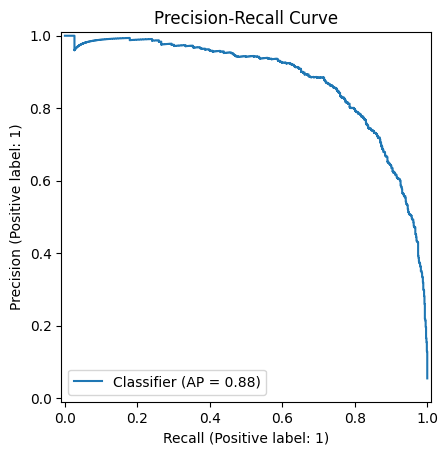

In [36]:
# plot precision-recall curve
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt
disp = PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba)
plt.title('Precision-Recall Curve')
plt.show()

In [38]:
#original precision recall f1
y_pred = final_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     15820
         1.0       0.84      0.76      0.80       910

    accuracy                           0.98     16730
   macro avg       0.91      0.87      0.89     16730
weighted avg       0.98      0.98      0.98     16730

